Notebook where I was looking at different emission structures -- Wigner, Gaussian, parabola -- in the fully analytic model.

In [1]:
##Importing packages
from custom_funcs import DPSS_fit, chan_avg, chan_select
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import least_squares
from scipy.ndimage import label, center_of_mass
from scipy.signal.windows import dpss
import os
from SSINS import INS

print("Packages imported.")

Packages imported.


In [2]:
#Loading in frequency axis mask
linemask = np.load('linemask.npy')

In [3]:
#Importing INS datafile, extracting masked and unmasked time and metric arrays
data_dir = "Data"
night = "109337_p2"
datapath = os.path.join(data_dir, night + "_SSINS_data.h5")
maskpath = os.path.join(data_dir, night + "_SSINS_mask.h5")

TV_dict = {
    'TV6': [1.74e8, 1.81e8],
    'TV7': [1.81e8, 1.88e8],
    'TV8': [1.88e8, 1.95e8],
    'TV9': [1.95e8, 2.02e8]
    }

ins = INS(datapath, telescope_name='MWA', mask_file=maskpath)
print(ins.metric_array.shape)
ins_subband, masked_ins, N_bl, N_freq = chan_select(ins, 'TV7', TV_dict)
time, amp = chan_avg(ins_subband)
masked_time, masked_amp = chan_avg(masked_ins)

print("Data initialized.")

invalid value encountered in multiply
invalid value encountered in divide


(780, 768, 4)
Data initialized.


sig_array has been reset


Looking for emissions -- the code fits to masked time series, takes residuals, then looks for masked events that are a certain minimum length and a certain minimum brightness. After identifying potential candidate, we

Fit constructed.
Initial guess: [1.76298339e+01 7.96291977e-03 4.39812429e-04 2.72287690e+01
 8.74995254e-03 6.24996610e-04]


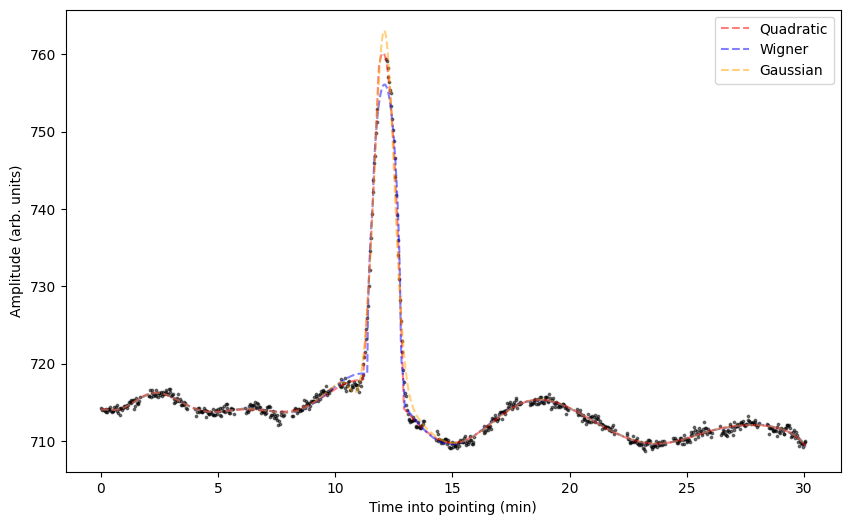

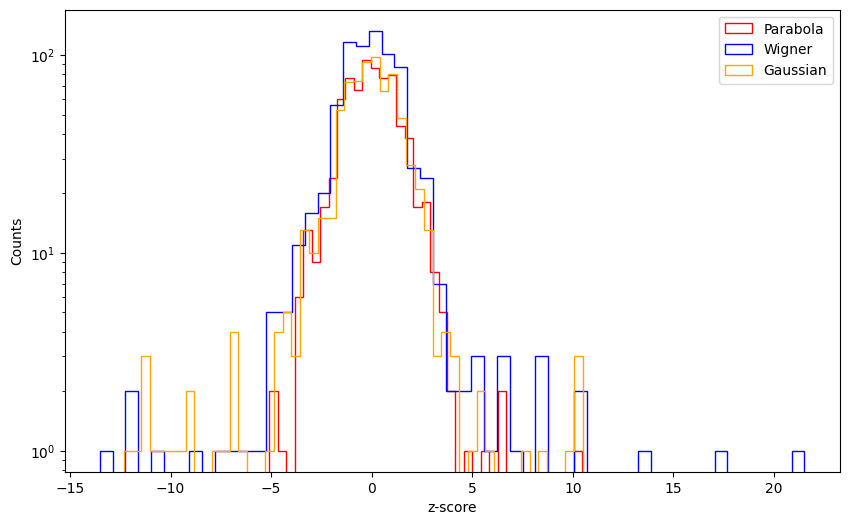

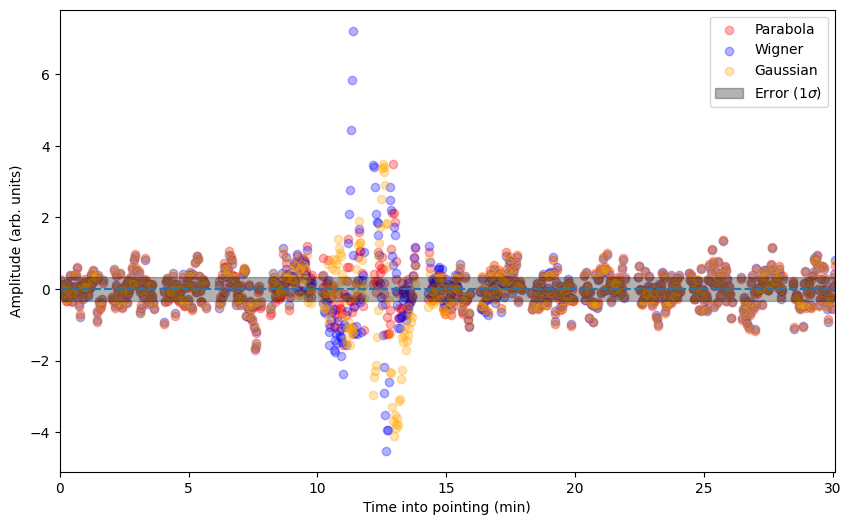

Reduced chi squared of parabola fit: 2.460685886734521
Reduced chi squared of Wigner fit: 5.691510407590773
Reduced chi squared of Gaussian fit: 5.297266104064768


" plt.figure(figsize=(10, 6))\nplt.scatter(masked_smooth_time, residuals)\nplt.fill_between(masked_smooth_time, -fit_err[filt_ind], fit_err[filt_ind], color='green', alpha=0.1)\nplt.fill_between(masked_smooth_time, -2*fit_err[filt_ind], 2*fit_err[filt_ind], color='green', alpha=0.1)\nplt.fill_between(masked_smooth_time, -3*fit_err[filt_ind], 3*fit_err[filt_ind], color='green', alpha=0.1)\nplt.xlim(np.min(masked_smooth_time), np.max(masked_smooth_time))\nplt.axhline(y=0, linestyle='--', color = 'k')\nplt.savefig('/home/andreili/ssins_env/test_res_fit.pdf') "

In [4]:
##Constructing masked fits
N_terms = 20
fit, coefficients, smooth_time, *cov = DPSS_fit(time, masked_time, masked_amp, 
                                                        N_win=4, N_terms=N_terms, N_bl=N_bl, N_freq=N_freq)

noise_err, param_err, fit_err = cov

print("Fit constructed.")

##Padding time, amplitude arrays
noise_err = np.diag(np.sqrt(noise_err))
padded_amp = np.full_like(smooth_time, np.nan, dtype=float)
indices = np.searchsorted(smooth_time, time)

##Finding residuals
padded_amp[indices] = amp
residuals = padded_amp - fit

##Filtering indices
filt_ind = ~np.isnan(residuals)
smooth_time = smooth_time - np.min(smooth_time[np.isfinite(smooth_time)])

## Find regions above significance threshold
threshold = 2 #In units of z-score with sigma = averaged thermal noise
mask = residuals > (threshold * noise_err)
labeled_mask, num_features = label(mask)  # Grouping contiguous regions
lengths = np.bincount(labeled_mask.flatten())[1:]

## Setting lower limit of 10 continguous points so that we know the emission is somewhat continuous.
emit_cands = np.where(lengths > 10, True, False) 
emit_cand_loc = np.where(emit_cands)[0] + 1
ind_com = np.array(center_of_mass(mask, labeled_mask, emit_cand_loc)).astype(int)

##Constructing the initial guesses -- emit_peaks being the amplitudes of the Gaussians, emit_com the means, emit_widths the STD.
emit_peaks = padded_amp[ind_com] - np.mean(padded_amp[filt_ind])
emit_com = smooth_time[ind_com]
emit_widths = []

for event in emit_cand_loc:
    indices = np.where(labeled_mask == event)[0]
    width = smooth_time[indices[-1]] - smooth_time[indices[0]]
    emit_widths.append(width)

emit_widths = np.array(emit_widths)
theta_0 = np.stack((emit_peaks.flatten(), emit_com.flatten(), emit_widths)).T.flatten()
print("Initial guess:", theta_0)


##Formatting our initial guess
p0 = np.concatenate((coefficients, theta_0))

##Defining the background + emissions joint model.
def parabola_model(time, *params):

    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    NW, K = 2, N_terms   
    basis = dpss(len(time), NW, K)
    design = basis.T
    
    background = design @ coeff

    emission = np.zeros_like(time)
    num_emissions = len(theta) // 3

    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")

    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        mask = np.where(np.abs(time - mu) <= sigma, True, False)
        emission[mask] += - amp * (time[mask] - mu - sigma) * (time[mask] - mu + sigma) /sigma**2

    return background + emission

def parabola_diff(params, time, vis_amp):

    amp_fit = parabola_model(time, *params)
    mask = np.isfinite(vis_amp)
    mod_res = amp_fit[mask] - padded_amp[mask]
    
    # Penalize flat regions in gaps (if any)
    if len(amp_fit[~mask]) > 0:
        gap_penalty = np.std(amp_fit[~mask])  # Penalize flatness in gaps
        mod_res = np.concatenate([mod_res, [gap_penalty]])

    return mod_res

def wigner_model(time, *params):

    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    NW, K = 2, N_terms   
    basis = dpss(len(time), NW, K)
    design = basis.T
    
    background = design @ coeff

    emission = np.zeros_like(time)
    num_emissions = len(theta) // 3

    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")

    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        mask = np.where(np.abs(time - mu) <= sigma, True, False)
        emission[mask] += amp * np.sqrt(sigma**2 - (time[mask] - mu)**2) / sigma

    return background + emission

def wigner_diff(params, time, vis_amp):

    amp_fit = wigner_model(time, *params)

    mask = np.isfinite(vis_amp)
    mod_res = amp_fit[mask] - padded_amp[mask]
    
    # Penalize flat regions in gaps (if any)
    if len(amp_fit[~mask]) > 0:
        gap_penalty = np.std(amp_fit[~mask])  # Penalize flatness in gaps
        mod_res = np.concatenate([mod_res, [gap_penalty]])

    return mod_res

parabola_result = least_squares(fun=parabola_diff, x0=p0, args=(smooth_time, padded_amp))
parabola_fit = parabola_result.x

wigner_result = least_squares(fun=wigner_diff, x0=p0, args=(smooth_time, padded_amp))
wigner_fit = wigner_result.x


def background_model(time, *params):

    coeff = params[:N_terms]
    
    NW, K = 2, N_terms   
    basis = dpss(len(time), NW, K)
    design = basis.T
    
    background = design @ coeff

    return background


def gaussian_model(time, *params):

    coeff = params[:N_terms]
    theta = params[N_terms:]
    
    NW, K = 2, N_terms   
    basis = dpss(len(time), NW, K)
    design = basis.T
    
    background = design @ coeff

    emission = np.zeros_like(time)
    num_emissions = len(theta) // 3

    if len(theta) % 3 != 0:
        raise ValueError("Incorrect array size for Gaussian fit parameters.")

    for k in range(num_emissions):
        amp, mu, sigma = theta[3*k : 3*k + 3]
        emission += amp/np.sqrt(2*np.pi*(sigma*0.55)**2) * np.exp(-0.5 * ((time - mu) / (sigma*0.55))**2)

    return background + emission

def gaussian_diff(params, time, vis_amp):

    #
    amp_fit = gaussian_model(time, *params)

    mask = np.isfinite(vis_amp)
    mod_res = amp_fit[mask] - padded_amp[mask]
    
    # Penalize flat regions in gaps (if any)
    if len(amp_fit[~mask]) > 0:
        gap_penalty = np.std(amp_fit[~mask])  # Penalize flatness in gaps
        mod_res = np.concatenate([mod_res, [gap_penalty]])

    return mod_res

gaussian_result = least_squares(fun=gaussian_diff, x0=p0, args=(smooth_time, padded_amp))
gaussian_fit = gaussian_result.x

plt.figure(figsize=(10, 6))
plt.plot(smooth_time*24*60, parabola_model(smooth_time, *parabola_fit), color='red', label='Quadratic', alpha=0.5, linestyle='--')
plt.plot(smooth_time*24*60, wigner_model(smooth_time, *wigner_fit), color='blue', label='Wigner', alpha=0.5, linestyle='--')
plt.plot(smooth_time*24*60, gaussian_model(smooth_time, *gaussian_fit), color='orange', label='Gaussian', alpha=0.5, linestyle='--')
#plt.plot(smooth_time*24*60, background_model(smooth_time, *parabola_fit), color='orange', label='DPSS', alpha=0.5, linestyle='-')
plt.legend()
plt.xlabel("Time into pointing (min)")
plt.ylabel("Amplitude (arb. units)")
plt.scatter(smooth_time*24*60, padded_amp, s=3, alpha=0.5, color='black')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist((padded_amp - parabola_model(smooth_time, *parabola_fit))/noise_err, bins='auto', color='red', label='Parabola', histtype='step')
plt.hist((padded_amp - wigner_model(smooth_time, *wigner_fit))/noise_err, bins='auto', color='blue', label='Wigner', histtype='step')
plt.hist((padded_amp - gaussian_model(smooth_time, *gaussian_fit))/noise_err, bins='auto', color='orange', label='Gaussian', histtype='step')
plt.legend()
plt.yscale('log')
plt.xlabel("z-score")
plt.ylabel("Counts")
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(smooth_time*24*60, padded_amp - parabola_model(smooth_time, *parabola_fit), color='red', label='Parabola', alpha=0.3)
plt.scatter(smooth_time*24*60, padded_amp - wigner_model(smooth_time, *wigner_fit), color='blue', label='Wigner', alpha=0.3)
plt.scatter(smooth_time*24*60, padded_amp - gaussian_model(smooth_time, *gaussian_fit), color='orange', label='Gaussian', alpha=0.3)
plt.axhline(y=0, linestyle='--')
plt.fill_between(smooth_time*24*60, -noise_err, noise_err, color='black', alpha=0.3, label=r'Error (1$\sigma$)')
plt.xlim(0, np.max(smooth_time[np.isfinite(smooth_time)])*24*60)
plt.legend()
plt.xlabel("Time into pointing (min)")
plt.ylabel("Amplitude (arb. units)")
plt.show()

def chi_square_redux(model, params):
    return np.sum(np.square((padded_amp[filt_ind] - model(smooth_time, *params)[filt_ind])/noise_err[filt_ind]))/(len(padded_amp[filt_ind]) - len(params))


print("Reduced chi squared of parabola fit:", chi_square_redux(parabola_model, parabola_fit))
print("Reduced chi squared of Wigner fit:", chi_square_redux(wigner_model, wigner_fit))
print("Reduced chi squared of Gaussian fit:", chi_square_redux(gaussian_model, gaussian_fit))


""" plt.figure(figsize=(10, 6))
plt.scatter(masked_smooth_time, residuals)
plt.fill_between(masked_smooth_time, -fit_err[filt_ind], fit_err[filt_ind], color='green', alpha=0.1)
plt.fill_between(masked_smooth_time, -2*fit_err[filt_ind], 2*fit_err[filt_ind], color='green', alpha=0.1)
plt.fill_between(masked_smooth_time, -3*fit_err[filt_ind], 3*fit_err[filt_ind], color='green', alpha=0.1)
plt.xlim(np.min(masked_smooth_time), np.max(masked_smooth_time))
plt.axhline(y=0, linestyle='--', color = 'k')
plt.savefig('/home/andreili/ssins_env/test_res_fit.pdf') """